# View Robustness Analysis

Box plots showing precision@k and recall@k variance across views.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from matplotlib.axes import Axes
from plotting_defaults import COLOR_MAP, delete_tex_cache, set_style

from fedaugment.utils import cd_to_git_root

cd_to_git_root()
delete_tex_cache()
set_style()

plots_dir = Path("analysis/plots/view-robustness")
plots_dir.mkdir(exist_ok=True, parents=True)

2026-01-28 22:24:57.477 | DEBUG    | fedaugment.utils.misc:cd_to_git_root:154 - Changed working directory to: /home/lbhm/Projects/fedaugment


In [2]:
# Load results per dataset and experiment group
base_path = Path("logs/view-robustness")

dataset_dfs: dict[str, pl.DataFrame] = {}
for dataset_path in base_path.iterdir():
    if not dataset_path.is_dir():
        continue
    dataset = dataset_path.name

    df_list: list[pl.DataFrame] = []
    for exp_group_path in dataset_path.iterdir():
        if not exp_group_path.is_dir():
            continue

        df_list.extend(
            pl.read_csv(f).with_columns(
                pl.lit(exp_group_path.name).alias("exp_group"),
                pl.lit(f.stem.split("-")[1]).alias("method"),
            )
            for f in exp_group_path.glob("*.csv")
        )

    dataset_dfs[dataset] = pl.concat(df_list).with_columns(pl.lit(dataset).alias("dataset"))

print(f"Loaded {len(dataset_dfs)} datasets")
dataset_dfs[next(iter(dataset_dfs.keys()))].head()

Loaded 5 datasets


query_id,precision@1,recall@1,max_precision@1,max_recall@1,hits@1,mrr@1,ap@1,precision@5,recall@5,max_precision@5,max_recall@5,hits@5,mrr@5,ap@5,precision@10,recall@10,max_precision@10,max_recall@10,hits@10,mrr@10,ap@10,precision@15,recall@15,max_precision@15,max_recall@15,hits@15,mrr@15,ap@15,precision@20,recall@20,max_precision@20,max_recall@20,hits@20,mrr@20,ap@20,precision@25,…,hits@30,mrr@30,ap@30,precision@35,recall@35,max_precision@35,max_recall@35,hits@35,mrr@35,ap@35,precision@40,recall@40,max_precision@40,max_recall@40,hits@40,mrr@40,ap@40,precision@45,recall@45,max_precision@45,max_recall@45,hits@45,mrr@45,ap@45,precision@50,recall@50,max_precision@50,max_recall@50,hits@50,mrr@50,ap@50,view,view_idx,ckpt_name,exp_group,method,dataset
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,str,str,str,str
"""agency_spending_noisy_0.pq::AG…",0.0,0.0,1.0,0.5,0.0,0.0,0.0,0.4,1.0,0.4,1.0,1.0,0.5,0.583333,0.2,1.0,0.2,1.0,1.0,0.5,0.583333,0.133333,1.0,0.133333,1.0,1.0,0.5,0.583333,0.1,1.0,0.1,1.0,1.0,0.5,0.583333,0.08,…,1.0,0.5,0.583333,0.057143,1.0,0.057143,1.0,1.0,0.5,0.583333,0.05,1.0,0.05,1.0,1.0,0.5,0.583333,0.044444,1.0,0.044444,1.0,1.0,0.5,0.583333,0.04,1.0,0.04,1.0,1.0,0.5,0.583333,"""distilroberta-dj_adpt""",0,"""webtable-cl_default-v=12-disti…","""12_views""","""cl_default""","""omnimatch_city_test"""
"""agency_spending_noisy_0.pq::AG…",0.0,0.0,1.0,0.5,0.0,0.0,0.0,0.4,1.0,0.4,1.0,1.0,0.5,0.5,0.2,1.0,0.2,1.0,1.0,0.5,0.5,0.133333,1.0,0.133333,1.0,1.0,0.5,0.5,0.1,1.0,0.1,1.0,1.0,0.5,0.5,0.08,…,1.0,0.5,0.5,0.057143,1.0,0.057143,1.0,1.0,0.5,0.5,0.05,1.0,0.05,1.0,1.0,0.5,0.5,0.044444,1.0,0.044444,1.0,1.0,0.5,0.5,0.04,1.0,0.04,1.0,1.0,0.5,0.5,"""distilroberta-dj_adpt""",0,"""webtable-cl_default-v=12-disti…","""12_views""","""cl_default""","""omnimatch_city_test"""
"""agency_spending_noisy_0.pq::BU…",0.0,0.0,1.0,0.333333,0.0,0.0,0.0,0.6,1.0,0.6,1.0,1.0,0.5,0.638889,0.3,1.0,0.3,1.0,1.0,0.5,0.638889,0.2,1.0,0.2,1.0,1.0,0.5,0.638889,0.15,1.0,0.15,1.0,1.0,0.5,0.638889,0.12,…,1.0,0.5,0.638889,0.085714,1.0,0.085714,1.0,1.0,0.5,0.638889,0.075,1.0,0.075,1.0,1.0,0.5,0.638889,0.066667,1.0,0.066667,1.0,1.0,0.5,0.638889,0.06,1.0,0.06,1.0,1.0,0.5,0.638889,"""distilroberta-dj_adpt""",0,"""webtable-cl_default-v=12-disti…","""12_views""","""cl_default""","""omnimatch_city_test"""
"""agency_spending_noisy_0.pq::PU…",0.0,0.0,1.0,0.5,0.0,0.0,0.0,0.4,1.0,0.4,1.0,1.0,0.5,0.5,0.2,1.0,0.2,1.0,1.0,0.5,0.5,0.133333,1.0,0.133333,1.0,1.0,0.5,0.5,0.1,1.0,0.1,1.0,1.0,0.5,0.5,0.08,…,1.0,0.5,0.5,0.057143,1.0,0.057143,1.0,1.0,0.5,0.5,0.05,1.0,0.05,1.0,1.0,0.5,0.5,0.044444,1.0,0.044444,1.0,1.0,0.5,0.5,0.04,1.0,0.04,1.0,1.0,0.5,0.5,"""distilroberta-dj_adpt""",0,"""webtable-cl_default-v=12-disti…","""12_views""","""cl_default""","""omnimatch_city_test"""
"""agency_spending_noisy_1.pq::BU…",1.0,0.25,1.0,0.25,1.0,1.0,0.25,0.6,0.75,0.8,1.0,1.0,1.0,0.6875,0.3,0.75,0.4,1.0,1.0,1.0,0.6875,0.266667,1.0,0.266667,1.0,1.0,1.0,0.758929,0.2,1.0,0.2,1.0,1.0,1.0,0.758929,0.16,…,1.0,1.0,0.758929,0.114286,1.0,0.114286,1.0,1.0,1.0,0.758929,0.1,1.0,0.1,1.0,1.0,1.0,0.758929,0.088889,1.0,0.088889,1.0,1.0,1.0,0.758929,0.08,1.0,0.08,1.0,1.0,1.0,0.758929,"""distilroberta-dj_adpt""",0,"""webtable-cl_default-v=12-disti…","""12_views""","""cl_default""","""omnimatch_city_test"""


In [3]:
# Compute per-view average metrics (mean across queries per view)
per_view_means_dict: dict[str, pl.DataFrame] = {}
for dataset, dataset_df in dataset_dfs.items():
    metric_cols = [c for c in dataset_df.columns if "@" in c]
    per_view_mean = dataset_df.group_by(["exp_group", "dataset", "method", "view"]).agg(
        [pl.col(c).mean().alias(c) for c in metric_cols]
    )
    per_view_means_dict[dataset] = per_view_mean

per_view_means_dict[next(iter(per_view_means_dict.keys()))].head()

exp_group,dataset,method,view,precision@1,recall@1,max_precision@1,max_recall@1,hits@1,mrr@1,ap@1,precision@5,recall@5,max_precision@5,max_recall@5,hits@5,mrr@5,ap@5,precision@10,recall@10,max_precision@10,max_recall@10,hits@10,mrr@10,ap@10,precision@15,recall@15,max_precision@15,max_recall@15,hits@15,mrr@15,ap@15,precision@20,recall@20,max_precision@20,max_recall@20,hits@20,…,mrr@25,ap@25,precision@30,recall@30,max_precision@30,max_recall@30,hits@30,mrr@30,ap@30,precision@35,recall@35,max_precision@35,max_recall@35,hits@35,mrr@35,ap@35,precision@40,recall@40,max_precision@40,max_recall@40,hits@40,mrr@40,ap@40,precision@45,recall@45,max_precision@45,max_recall@45,hits@45,mrr@45,ap@45,precision@50,recall@50,max_precision@50,max_recall@50,hits@50,mrr@50,ap@50
str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""12_views""","""omnimatch_city_test""","""cl_optim""","""distilroberta-dj_adpt""",0.551724,0.192334,1.0,0.462151,0.551724,0.551724,0.192334,0.48319,0.816108,0.581897,0.96934,0.954741,0.716092,0.608083,0.286638,0.916801,0.314224,1.0,0.976293,0.719048,0.656828,0.197701,0.947573,0.209483,1.0,0.984914,0.719801,0.664328,0.150216,0.959339,0.157112,1.0,0.989224,…,0.720063,0.666616,0.100575,0.963314,0.104741,1.0,0.989224,0.720063,0.666909,0.086638,0.968056,0.089778,1.0,0.991379,0.720126,0.66726,0.07597,0.968774,0.078556,1.0,0.991379,0.720126,0.667372,0.067529,0.968774,0.069828,1.0,0.991379,0.720126,0.667372,0.060862,0.969552,0.062845,1.0,0.991379,0.720126,0.667457
"""12_views""","""omnimatch_city_test""","""la2m_nopca""","""distilroberta-dj_adpt""",0.556034,0.194902,1.0,0.462151,0.556034,0.556034,0.194902,0.482328,0.813442,0.581897,0.96934,0.946121,0.716523,0.611421,0.287716,0.923678,0.314224,1.0,0.976293,0.720693,0.661586,0.199138,0.955363,0.209483,1.0,0.987069,0.72158,0.669834,0.150216,0.960592,0.157112,1.0,0.989224,…,0.721801,0.671118,0.100575,0.965821,0.104741,1.0,0.991379,0.721801,0.671236,0.086453,0.968592,0.089778,1.0,0.991379,0.721801,0.671477,0.075808,0.972004,0.078556,1.0,0.993534,0.721857,0.671647,0.067481,0.972743,0.069828,1.0,0.993534,0.721857,0.671748,0.060733,0.972743,0.062845,1.0,0.993534,0.721857,0.671748
"""12_views""","""omnimatch_city_test""","""cl_default""","""llama_nemotron_8b-dj_adpt""",0.549569,0.190681,1.0,0.462151,0.549569,0.549569,0.190681,0.465948,0.789211,0.581897,0.96934,0.935345,0.705675,0.582907,0.273922,0.890521,0.314224,1.0,0.965517,0.709765,0.627006,0.19454,0.935706,0.209483,1.0,0.982759,0.711202,0.638118,0.149353,0.953758,0.157112,1.0,0.987069,…,0.711429,0.642223,0.100359,0.960376,0.104741,1.0,0.987069,0.711429,0.642631,0.086268,0.96236,0.089778,1.0,0.987069,0.711429,0.642869,0.075593,0.963168,0.078556,1.0,0.987069,0.711429,0.642964,0.067385,0.964736,0.069828,1.0,0.987069,0.711429,0.643145,0.06069,0.965167,0.062845,1.0,0.987069,0.711429,0.64318
"""12_views""","""omnimatch_city_test""","""cl_default""","""gtr_t5-dj_adpt""",0.540948,0.187125,1.0,0.462151,0.540948,0.540948,0.187125,0.480172,0.807637,0.581897,0.96934,0.943966,0.704095,0.592827,0.290302,0.930598,0.314224,1.0,0.978448,0.70879,0.649947,0.200144,0.956618,0.209483,1.0,0.984914,0.709326,0.656829,0.151832,0.966973,0.157112,1.0,0.989224,…,0.709572,0.659087,0.102945,0.981034,0.104741,1.0,0.991379,0.709646,0.660247,0.088978,0.991487,0.089778,1.0,0.99569,0.709781,0.661017,0.077856,0.991487,0.078556,1.0,0.99569,0.709781,0.661017,0.069205,0.991487,0.069828,1.0,0.99569,0.709781,0.661017,0.062284,0.991487,0.062845,1.0,0.99569,0.709781,0.661017
"""12_views""","""omnimatch_city_test""","""cl_optim""","""qwen3_06b-dj_adpt""",0.530172,0.183417,1.0,0.462151,0.530172,0.530172,0.183417,0.488793,0.829175,0.581897,0.96934,0.956897,0.70431,0.604632,0.291164,0.942543,0.314224,1.0,0.982759,0.707651,0.656789,0.20287

12_views-freyja-k=10


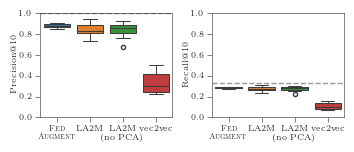

12_views-omnimatch_city_test-k=10


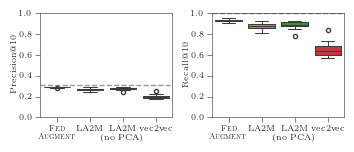

12_views-omnimatch_culture_test-k=10


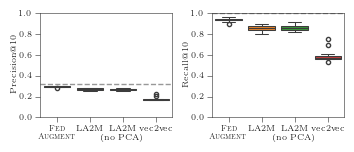

12_views-santos-union-k=10


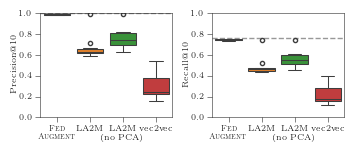

08_views-webtable-union-k=10


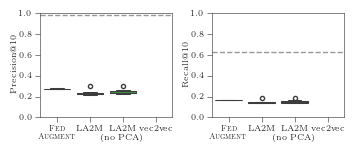

12_views-freyja-k=20


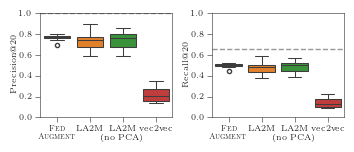

12_views-omnimatch_city_test-k=20


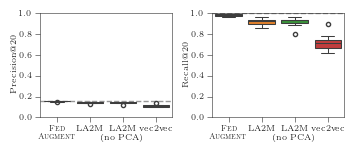

12_views-omnimatch_culture_test-k=20


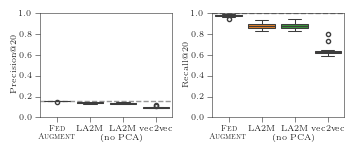

12_views-santos-union-k=20


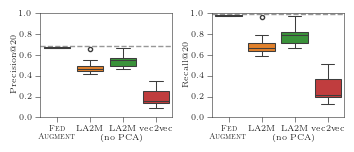

08_views-webtable-union-k=20


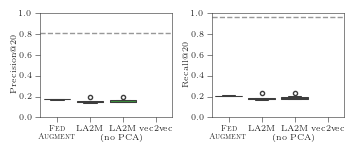

In [4]:
for k in [10, 20]:
    for exp_group, datasets in [
        ("12_views", ["freyja", "omnimatch_city_test", "omnimatch_culture_test", "santos-union"]),
        ("08_views", ["webtable-union"]),
    ]:
        for dataset in datasets:
            per_view_means = per_view_means_dict[dataset]
            if len(per_view_means) == 0:
                continue

            exp_df = per_view_means.filter(pl.col("exp_group") == exp_group)

            # Max width: 241.14 pt
            fig, axes = plt.subplots(1, 2, figsize=(3.525, 1.5), layout="tight")
            for row_idx, metric in enumerate(["precision", "recall"]):
                ax: Axes = axes[row_idx]

                max_metric_value: float = exp_df[f"max_{metric}@{k}"].max()  # type: ignore[arg-type]
                ax.hlines(
                    y=max_metric_value,
                    xmin=-0.5,
                    xmax=3.5,
                    linestyles="--",
                    colors=COLOR_MAP["max_metric"],
                    alpha=0.8,
                )
                # ax.text(
                #     x=3.5,
                #     y=max_metric_value - 0.01,
                #     s=f"Max {metric}@{k}",
                #     ha="right",
                #     va="top",
                #     fontsize=5,
                #     color=colors["max_metric"],
                # )

                sns.boxplot(
                    data=exp_df,
                    x="method",
                    y=f"{metric}@{k}",
                    ax=ax,
                    order=["cl_optim", "la2m_default", "la2m_nopca", "v2v"],
                    hue="method",
                    hue_order=["cl_optim", "la2m_default", "la2m_nopca", "v2v"],
                    palette=COLOR_MAP,
                    linewidth=0.75,
                )
                ax.set_xlabel("")
                ax.set_ylabel(f"{metric.capitalize()}@{k}")
                ax.set_ylim(0, 1)
                ax.set_xticks(
                    [0, 1, 2, 3],
                    labels=[
                        r"\textsc{Fed}" + "\n" + r"\textsc{Augment}",
                        "LA2M",
                        "LA2M\n(no PCA)",
                        "vec2vec",
                    ],
                )

            fig.savefig(
                plots_dir / f"{exp_group}-{dataset}-k={k}.pdf",
                pad_inches=0.00,
                bbox_inches="tight",
            )
            print(f"{exp_group}-{dataset}-k={k}")
            plt.show()